## Import libraries

In [1]:
import numpy as np
import tomopy
from helperFunctions import MoviePlotter, convert_to_numpy, degree_to_positiveRadians
from tomoDataClass import tomoData

[gpu] active backends: cupy, torch-GPU, svmbir


## Load Co-doped Data

Instead of a simulated Shepp3D phantom, this notebook uses the real Co-doped phase projections saved in the `tomoMono` folder:

- `Co_doped_phase_stack.tiff` — the 3D projection stack (angle, y, x)
- `Co_doped_angles.npy` — the tilt angle (degrees) for each slice, index-matched to the stack
- `Co_doped_slice_order.csv` — human-readable record of `slice_index, scan, angle_deg`

Because this is measured experimental data, it already contains real misalignment and noise, so the phantom-only `jitter()` / `add_noise()` steps are dropped.

In [2]:
# File paths for the saved Co-doped data
PHASE_STACK = 'Co_doped_phase_stack.tiff'
ANGLES_FILE = 'Co_doped_angles.npy'
SLICE_ORDER = 'Co_doped_slice_order.csv'

algorithm = 'SIRT_CUDA'

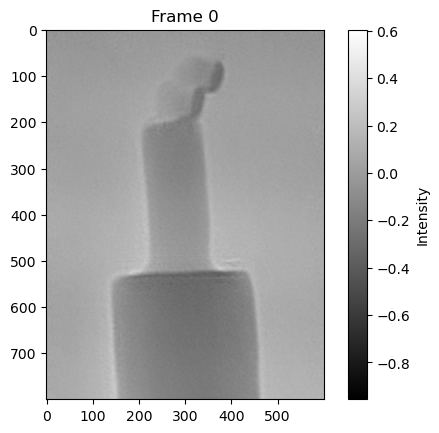

In [3]:
# Load the phase projection stack (angle, y, x)
projections, scale_info = convert_to_numpy(PHASE_STACK)
projections = projections.astype(np.float32)
downsample = 1
projections = projections[:, 60:-262:downsample, 75:-87:downsample] #Crop to be good size 1000,600 at full res2
print(projections.shape)
print("Measured Co-doped phase projections")
MoviePlotter(projections)  # Plots each projection

In [4]:
# Load the per-slice tilt angles (saved in degrees) and convert to positive radians
angles_deg = np.load(ANGLES_FILE)
angles = degree_to_positiveRadians(angles_deg)
angles = (angles + np.pi) % (2 * np.pi)
print(f"{len(angles)} angles, spanning {angles_deg.min()} to {angles_deg.max()} degrees")
assert len(angles) == projections.shape[0], "angle count must match number of projections"
print(angles)

166 angles, spanning -90.0 to 90.0 degrees
[1.5707965 1.6057029 1.6231561 1.6580634 1.6755166 1.6929698 1.710423
 1.7278762 1.7453294 1.7627826 1.7802358 1.797689  1.8325963 1.8500495
 1.8675027 1.8849559 1.9024091 1.9198623 1.9373155 1.9547687 1.989675
 2.0071292 2.0245824 2.0420356 2.0594888 2.076942  2.0943952 2.1118484
 2.1293015 2.1467547 2.164208  2.1991153 2.2165685 2.2340217 2.2514749
 2.268928  2.2863812 2.3038344 2.3212876 2.3387418 2.356195  2.3736482
 2.3911014 2.4085546 2.4260077 2.443461  2.4609141 2.4783673 2.5132747
 2.5307279 2.548181  2.5656343 2.5830874 2.6179938 2.635447  2.6529002
 2.6703534 2.6878076 2.7052608 2.722714  2.7401671 2.7576203 2.7750735
 2.7925267 2.827433  2.8448873 2.8797936 2.8972468 2.9147    2.9321532
 2.9496064 2.9670596 2.9845128 3.001966  3.0194201 3.0368733 3.0543265
 3.0717797 3.089233  3.106686  3.1241393 3.1415927 3.159046  3.1764991
 3.1939528 3.211406  3.2288592 3.2463124 3.2637656 3.2986724 3.3161256
 3.3335788 3.3510325 3.3684857 3.403

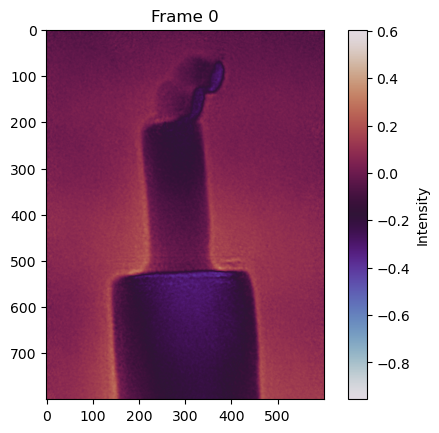

In [5]:
# croppedProjections = projections[::, 60:-60:4, 75:-75:4]
tomo = tomoData(projections, angles)
print("Measured projections (real misalignment + noise already present)")
tomo.makeNotebookProjMovie()

## Align Data

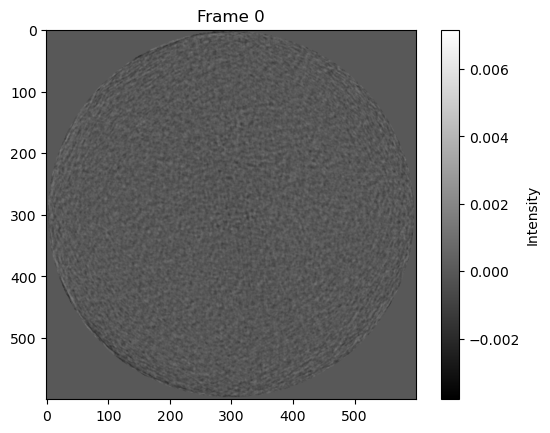

In [6]:
#Show bad reconstruction prior to alignment
tomo.reconstruct(algorithm=algorithm, find_center_method=None)
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)

# print(tomo.ang)



Sinogram consistency:
  x_cm (horizontal) — RMSE: 1.9013 px  |  R²: 0.265359
  y_cm (vertical)   — RMSE: 4.5965 px  |  R²: 0.000000
  Combined RMSE:       3.5173 px
Computing reprojections from reconstruction for sinogram comparison...


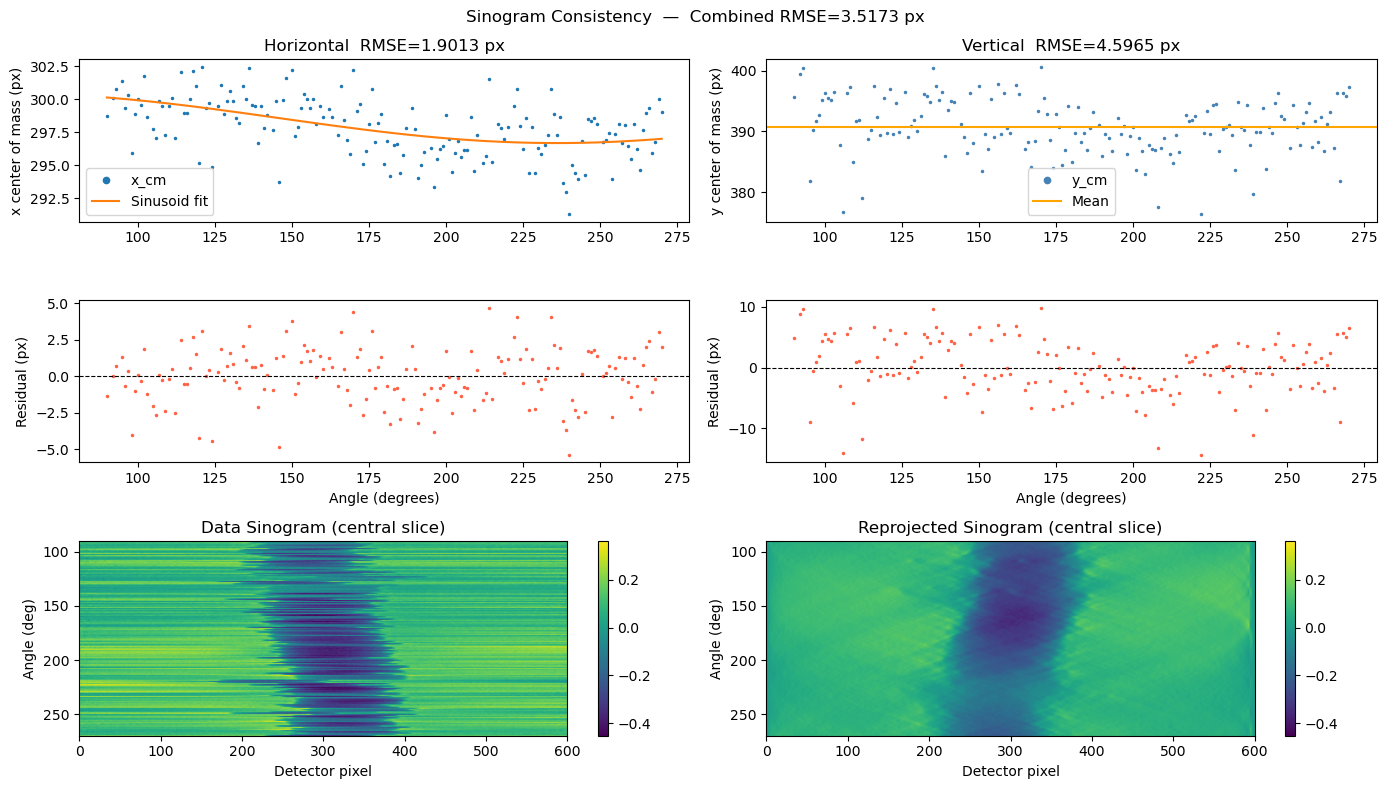

In [7]:
combined_rmse, x_rmse, y_rmse, x_cm, y_cm = tomo.sinogram_consistency_score(plot=True)

In [8]:
# tomo.reset_workingProjections() #You can pass x_size/y_size for tighter cropping
# tomo.normalize(isPhaseData=True)
# tomo.cross_correlate_align(tolerance=0.001, max_iterations=20, stepRatio=0.9, yROI_Range=None, xROI_Range=None)
# tomo.projection_matching_alignment(max_iterations=5, tolerance=0.05, algorithm='gridrec', standardize=False)
# tomo.make_updates_shift()

tomo.reset_workingProjections() #You can pass x_size/y_size for tighter cropping
tomo.normalize(isPhaseData=True)
tomo.center_projections(method=None)

tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.8,
        downsample=4, use_grad=False,
        yROI_Range=None, xROI_Range=None, isFull360=False,
        plot=True
    )
tomo.center_projections(method=None)
tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.8,
        downsample=2, use_grad=False,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample,460//downsample],
        # yROI_Range=None,
        # xROI_Range=None,
        isFull360=False,
        plot=True
    )
tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.8,
        downsample=1, use_grad=False,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample,460//downsample],
        # yROI_Range=None,
        # xROI_Range=None,
        isFull360=False,
        plot=True
    )
tomo.center_projections(method=None)

tomo.make_updates_shift()


tomo.makeNotebookProjMovie()



Normalizing projections


CompileException: nvrtc: warning: Architectures prior to '<compute/sm>_75' are deprecated and may be removed in a future release
/home/ljh79/.conda/envs/tomoMono/lib/python3.12/site-packages/cupy/_core/include/cupy/carray.cuh(57): catastrophic error: cannot open source file "cuda_fp16.h"
  #include <cuda_fp16.h>
                        ^

1 catastrophic error detected in the compilation of "/tmp/tmp28hmnpa5/f7b4504b45db463cf6af19c0a7a968a3537524c5.cubin.cu".
Compilation terminated.


In [ ]:
tomo.center_projections(method=None)
tomo.projection_matching_alignment(
        levels=1, scale=1, iterations_per_level=[5],
        tolerance=0.0, algorithm=algorithm, standardize=False, use_grad=True,
        shift_method='optical_flow', of_sigma=2.0, stepRatio=0.8, centering_method=None,
        plot=True,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample, 460//downsample],
        # xROI_Range=None,
        # yROI_Range=None,
    )
tomo.make_updates_shift()
tomo.makeNotebookProjMovie()


In [ ]:
tomo.reconstruct(algorithm=algorithm, find_center_method=None)
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

# Save the reconstruction as a tiff file from helperFunctions.py save_to_tiff 
# def convert_to_tiff(numpy_data, file_location, scale_info=None):
from helperFunctions import convert_to_tiff
convert_to_tiff(-tomo.recon, f'Co_doped_reconstruction_{downsample}xds.tiff', scale_info=scale_info)

## Assess Alignment Quality

Now that alignment and reconstruction are done, we quantify how good the alignment is with two metrics:

- **Reprojection Consistency Score (RCS)** — *the most reliable metric for alignment quality.* It reprojects the reconstructed volume at every angle and compares it against the measured projections (per-angle NRMSE). Lower is better (`< 0.10` is excellent), and the per-angle bar chart flags any projections that are still misaligned.
- **Sinogram Consistency Score** — *a rough gauge, not a reliable score.* It checks the Helgason-Ludwig center-of-mass conditions on the sinogram. Use it to get a coarse sense of how close the alignment is, to spot outlier projections, and to view the central-slice sinogram.

(For *reconstruction* quality / resolution rather than alignment, use `fourier_shell_correlation` — the gold-standard half-dataset FSC metric.)

In [ ]:
# Reprojection Consistency Score — best metric of alignment quality (lower is better)
rcs, per_angle_nrmse, _ = tomo.reprojection_consistency_score(plot=True)

In [ ]:
# Sinogram Consistency Score — rough gauge of alignment + central-slice sinogram view
combined_rmse, x_rmse, y_rmse, x_cm, y_cm = tomo.sinogram_consistency_score(plot=True)